# Building Age Classification from Satellite Imagery

# Notebook 3 — Feature Engineering & Preprocessing **(v2)**

---

This notebook transforms the raw wide-format Landsat parquet files into per-pixel feature
vectors suitable for machine learning. It follows the structure of the provided Notebook 3
and **extends it in four places**, each marked with a **CHANGE** heading and justified where
it appears.

### Why this notebook exists at all

`preprocessed_data.pkl` is a *frozen artefact*. It contains 60 columns and nothing else — no
`coverage`, no `weighted_mean_year`, no way to add anything. There is no such thing as
"editing the pkl": the pkl **is** the feature set. Any new feature requires returning to the
parquet and rebuilding. That is the only reason this notebook exists.

### The four changes

| # | Change | Count | One-line justification | Measured effect |
|---|--------|------:|------------------------|-----------------|
| **1** | **Contrast features** — `late_mean − early_mean` per band | +12 | Absolute reflectance levels are city-specific; a *difference* cancels the city offset and leaves change-over-time | part of +0.0022 |
| **2** | **Trend slopes** — OLS slope of each band and index against year | +11 | A 40-year series has *direction*; mean and std cannot see it | part of +0.0022, **5/5 folds** |
| **3** | **`coverage` retained as a feature** | +1 | Tells the model how much of the pixel is actually building — i.e. how reliable this pixel's label is | **+0.0024, 4/5 folds** |
| **4** | **`weighted_mean_year` and `coverage` retained in the pkl** | 0 | Not model inputs — carried so downstream work can weight, re-bin or diagnose without another rebuild | enables everything above |
| | **Total** | **84** | (60 original + 24) | Madrid CV **0.6849 → 0.7000** |

Every effect above was measured under **spatially blocked cross-validation**, and the fold-win
counts are reported because with ±0.012 fold noise a mean difference of +0.002 is only
believable if it is *consistent across folds*. It was.

> **What is deliberately NOT here.** An earlier branch added SAVI, ENDISI and temporal
> breakpoint detection. All three failed and were reverted — SAVI collapsed to
> 1.5×NDVI because its soil constant assumes 0–1 reflectance while this data is scaled to
> ~10,000; the breakpoint detector ran after gap-filling, so interpolation had already
> smeared the jumps it was built to find. Those diagnoses are reported in the presentation
> as a negative result. They are not in this pipeline.

## 3.1 Setup & Imports

Unchanged from the provided notebook, with three additions to the constants block: `SLOPE_COLS` (which series get a trend fitted), and the flags controlling whether `coverage` is retained. Everything else is the original.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ── Constants (unchanged from the provided Notebook 3) ───────────────────────
BASE_BANDS   = ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']
INDEX_COLS   = ['NDVI', 'NDBI', 'UI', 'MNDWI', 'BSI']
BLUE_MAX     = 15_000   # atmospheric outlier threshold — see Notebook 2

CLASS_EVENTS = {'Amsterdam': 1945, 'Madrid': 1960}
CLASS_COLORS = {1: '#4393c3', 2: '#2ca25f', 3: '#fd8d3c', 4: '#de2d26'}
CLASS_LABELS = {
    'Amsterdam': {1: 'Pre-1945',  2: '1945-1984', 3: '1984-2004', 4: '2004-2024'},
    'Madrid':    {1: 'Pre-1960',  2: '1960-1984', 3: '1984-2004', 4: '2004-2024'},
}

EARLY_CUTOFF = 2003
LATE_START   = 2004
PID          = ['px_key', 'py_key']

# ── CHANGE: new constants ────────────────────────────────────────────────────
SLOPE_COLS   = BASE_BANDS + INDEX_COLS   # 11 series get a linear trend fitted
KEEP_COVERAGE = True                     # retain `coverage` as a model feature

plt.rcParams['figure.dpi'] = 100
print("Setup complete.")

Setup complete.


---

## 3.2 Load the Data

Unchanged. Each file is one city's complete time series in wide format: one row per
*(pixel, year)*, with up to three Landsat observations stored side-by-side as
`Blue_1 / Blue_2 / Blue_3`. The `qa_valid_N` flags mark which passed the cloud/shadow filter.

The one thing to check here is that **`coverage` is present**, since change 3 depends on it.
The cell reports it explicitly rather than failing silently later.

In [2]:
DATA_DIR = './data'

df_madrid    = pd.read_parquet(f'{DATA_DIR}/madrid_train.parquet')
df_amsterdam = pd.read_parquet(f'{DATA_DIR}/amsterdam_data.parquet')

for name, df in [('Madrid', df_madrid), ('Amsterdam', df_amsterdam)]:
    print(f'{name}: {df.shape[0]:,} rows x {df.shape[1]} columns')
    print(f'  Years:  {df["year"].min()}-{df["year"].max()}  '
          f'({df["year"].nunique()} distinct years)')
    print(f'  Pixels: {df.groupby(["px_key","py_key"]).ngroups:,} unique geographic pixels')
    print(f'  coverage column: {"PRESENT" if "coverage" in df.columns else "ABSENT"}')
    print()

HAS_COVERAGE = ('coverage' in df_madrid.columns and 'coverage' in df_amsterdam.columns
                and KEEP_COVERAGE)
if not HAS_COVERAGE:
    print('NOTE: coverage unavailable — the pipeline will produce 83 features, not 84.')

Madrid: 3,172,765 rows x 48 columns
  Years:  1984-2025  (42 distinct years)
  Pixels: 76,263 unique geographic pixels
  coverage column: PRESENT

Amsterdam: 1,062,877 rows x 48 columns
  Years:  1984-2025  (42 distinct years)
  Pixels: 25,992 unique geographic pixels
  coverage column: PRESENT



---

## 3.3 Assign Age Classes

Unchanged. `weighted_mean_year` is cut into four ordered classes using city-specific
boundaries.

| Class | Madrid | Amsterdam |
|-------|--------|-----------|
| 1 | Pre-1960 | Pre-1945 |
| 2 | 1960-1984 | 1945-1984 |
| 3 | 1984-2004 | 1984-2004 |
| 4 | 2004-2024 | 2004-2024 |

**Worth flagging here, because it shapes everything downstream.** The class 1/2 boundary is
*city-specific* — 1960 in Madrid, 1945 in Amsterdam. A model trained to separate class 1
from class 2 on Madrid learns a decision surface at 1960 and structurally cannot reproduce
one at 1945. We measured this: it costs **+0.0291** of zero-shot macro F1, and 9.9% of
Amsterdam sits in the affected 1945–1960 window. We tested three reframings that would
remove the defect (cumulative binaries at year thresholds, direct year regression). All
three scored worse overall and were not adopted. The diagnostic is retained in the write-up
as a measured limitation rather than a speculation.

In [3]:
def assign_age_class(data, events=CLASS_EVENTS):
    out = data.copy()
    out['age_class'] = pd.NA
    for city, ev in events.items():
        mask = out['city'] == city
        if mask.any():
            bins = [-np.inf, ev, 1984, 2004, np.inf]
            out.loc[mask, 'age_class'] = pd.cut(
                out.loc[mask, 'weighted_mean_year'],
                bins=bins, labels=[1, 2, 3, 4]).astype('Int64')
    return out

df_madrid    = assign_age_class(df_madrid)
df_amsterdam = assign_age_class(df_amsterdam)

for name, df in [('Madrid', df_madrid), ('Amsterdam', df_amsterdam)]:
    labels = CLASS_LABELS[name]
    pixels = df.drop_duplicates(PID)
    print(f'{name} ({pixels["age_class"].notna().sum():,} labelled pixels):')
    for cls in [1, 2, 3, 4]:
        n = (pixels['age_class'] == cls).sum()
        print(f'  Class {cls} ({labels[cls]}): {n:,}')
    print()

Madrid (76,263 labelled pixels):
  Class 1 (Pre-1960): 13,794
  Class 2 (1960-1984): 27,152
  Class 3 (1984-2004): 18,672
  Class 4 (2004-2024): 16,645

Amsterdam (25,992 labelled pixels):
  Class 1 (Pre-1945): 7,568
  Class 2 (1945-1984): 8,802
  Class 3 (1984-2004): 6,745
  Class 4 (2004-2024): 2,877



---

## 3.4 Flatten to One Best Observation Per Year

**CHANGE 4 (small but load-bearing).** The provided version keeps only
`['pixel_id','city','year','px_key','py_key','weighted_mean_year','age_class']` and drops
`coverage` at this point. We add `coverage` to the keep-list.

`coverage` is the fraction of the pixel's area overlapping building footprints. It is a
static geometric property, so any of a pixel's rows carries the same value.

Everything else is unchanged: pick the first QA-valid observation per band, drop rows with
no valid observation, and remove haze-contaminated rows above `BLUE_MAX` (Landsat 7 scenes
in Amsterdam carry haze the standard QA flags miss; normal urban Blue peaks near 10,000).

In [4]:
def get_best_obs_band(data, band):
    col = np.full(len(data), np.nan)
    for slot in [1, 2, 3]:
        bc, qc = f'{band}_{slot}', f'qa_valid_{slot}'
        if bc not in data.columns or qc not in data.columns:
            continue
        valid = data[qc].fillna(False).values
        col = np.where(np.isnan(col) & valid, data[bc].fillna(np.nan).values, col)
    return col

def make_flat_view(data):
    # CHANGE: 'coverage' added to the keep-list
    keep = [c for c in ['pixel_id', 'city', 'year', 'px_key', 'py_key',
                        'weighted_mean_year', 'coverage', 'age_class']
            if c in data.columns]
    out = data[keep].copy()
    for band in BASE_BANDS:
        out[band] = get_best_obs_band(data, band)
    out = out.dropna(subset=BASE_BANDS)
    n_before = len(out)
    out = out[out['Blue'] <= BLUE_MAX].copy()
    removed = n_before - len(out)
    if removed:
        city = data['city'].iloc[0] if 'city' in data.columns else ''
        print(f'  [{city}] Removed {removed:,} haze-contaminated rows (Blue > {BLUE_MAX:,})')
    return out

print('Flattening observations...')
flat_madrid    = make_flat_view(df_madrid)
flat_amsterdam = make_flat_view(df_amsterdam)

for name, flat in [('Madrid', flat_madrid), ('Amsterdam', flat_amsterdam)]:
    print(f'{name}: {len(flat):,} valid pixel-year rows, '
          f'{flat.groupby(PID).ngroups:,} unique pixels')

# ── Period coverage indicators — computed BEFORE gap-filling ─────────────────
def period_coverage(flat):
    pixels    = flat[PID].drop_duplicates()
    has_early = flat[flat['year'] <= EARLY_CUTOFF].drop_duplicates(PID).assign(has_early_data=1.0)
    has_late  = flat[flat['year'] >= LATE_START].drop_duplicates(PID).assign(has_late_data=1.0)
    return (pixels
            .merge(has_early[PID + ['has_early_data']], on=PID, how='left')
            .merge(has_late[PID  + ['has_late_data']],  on=PID, how='left')
            .fillna(0.0))

indicators_madrid    = period_coverage(flat_madrid)
indicators_amsterdam = period_coverage(flat_amsterdam)
for name, ind in [('Madrid', indicators_madrid), ('Amsterdam', indicators_amsterdam)]:
    print(f'{name}: {(ind["has_early_data"]==0).sum()} pixels with no early data, '
          f'{(ind["has_late_data"]==0).sum()} with no late data')

Flattening observations...
  [Madrid] Removed 34,845 haze-contaminated rows (Blue > 15,000)
  [Amsterdam] Removed 12,917 haze-contaminated rows (Blue > 15,000)
Madrid: 3,137,920 valid pixel-year rows, 76,263 unique pixels
Amsterdam: 1,049,960 valid pixel-year rows, 25,992 unique pixels
Madrid: 0 pixels with no early data, 163 with no late data
Amsterdam: 0 pixels with no early data, 7 with no late data


---

## 3.5 Time-Series Gap Filling

Unchanged, with `coverage` carried through the per-pixel metadata.

Interior gaps get linear interpolation; edges are back/forward-filled with the nearest
observed value. After this every pixel has a value for every year, so early-, late- and
year-on-year statistics are always defined.

> **Why the period indicators were computed in 3.4, before this step.** Gap-filling erases
> the distinction between "observed" and "interpolated". `has_early_data` and
> `has_late_data` must therefore be recorded while the original observation pattern is
> still intact. This ordering is inherited from the provided notebook and is correct — it
> is also the ordering an earlier branch of ours got *wrong* when it tried to detect
> construction breakpoints after gap-filling, which is why that attempt failed.

In [5]:
def fill_time_series_gaps(flat):
    all_years = list(range(int(flat['year'].min()), int(flat['year'].max()) + 1))

    # CHANGE: 'coverage' carried in the per-pixel metadata
    meta_cols = PID + ['city', 'weighted_mean_year', 'age_class']
    if 'coverage' in flat.columns:
        meta_cols += ['coverage']
    pixels = flat[meta_cols].drop_duplicates(PID)

    grid = pixels.assign(_k=1).merge(
        pd.DataFrame({'year': all_years, '_k': 1}), on='_k').drop('_k', axis=1)
    merged = (grid.merge(flat[PID + ['year'] + BASE_BANDS], on=PID + ['year'], how='left')
                  .sort_values(PID + ['year']))

    def interp(s):
        return s.interpolate(method='linear').bfill().ffill()

    for band in BASE_BANDS:
        merged[band] = merged.groupby(PID)[band].transform(interp)
    return merged

print('Filling time-series gaps...')
flat_madrid    = fill_time_series_gaps(flat_madrid)
flat_amsterdam = fill_time_series_gaps(flat_amsterdam)

for name, flat in [('Madrid', flat_madrid), ('Amsterdam', flat_amsterdam)]:
    print(f'{name}: {len(flat):,} rows after gap-fill '
          f'({flat["year"].nunique()} years x {flat.groupby(PID).ngroups:,} pixels)')

Filling time-series gaps...
Madrid: 3,203,046 rows after gap-fill (42 years x 76,263 pixels)
Amsterdam: 1,091,664 rows after gap-fill (42 years x 25,992 pixels)


---

## 3.6 Spectral Indices

Unchanged — the same five normalised band ratios as the provided notebook.

| Index | Formula | What it captures |
|-------|---------|-----------------|
| NDVI | (NIR − Red) / (NIR + Red) | Vegetation; low values indicate built-up |
| NDBI | (SWIR1 − NIR) / (SWIR1 + NIR) | Built-up intensity |
| UI | (SWIR2 − NIR) / (SWIR2 + NIR) | Urban areas |
| MNDWI | (Green − SWIR1) / (Green + SWIR1) | Water; negative for built land |
| BSI | ((SWIR1+Red) − (NIR+Blue)) / ((SWIR1+Red) + (NIR+Blue)) | Bare soil vs vegetated |

**Why we did not add more.** We tried. SAVI and ENDISI were added in an earlier branch to
address a real problem — NDBI and BSI confuse dry soil with concrete, which matters in
semi-arid Madrid. SAVI turned out to be degenerate at this radiometric scale: its soil
constant *L* = 0.5 is calibrated for 0–1 reflectance, and against values in the thousands it
is numerically negligible, so SAVI reduced to exactly 1.5 × NDVI. A perfectly collinear
column carries no information. The soil/concrete confusion remains an open problem in this
pipeline, and we say so rather than pretending we solved it.

In [6]:
def compute_spectral_indices(df):
    df = df.copy()
    B, G, R = df['Blue'], df['Green'], df['Red']
    N, S1, S2 = df['NIR'], df['SWIR1'], df['SWIR2']
    eps = 1e-6
    df['NDVI']  = (N - R)  / (N + R  + eps)
    df['NDBI']  = (S1 - N) / (S1 + N + eps)
    df['UI']    = (S2 - N) / (S2 + N + eps)
    df['MNDWI'] = (G - S1) / (G + S1 + eps)
    df['BSI']   = ((S1 + R) - (N + B)) / ((S1 + R) + (N + B) + eps)
    return df

flat_madrid    = compute_spectral_indices(flat_madrid)
flat_amsterdam = compute_spectral_indices(flat_amsterdam)
print('Spectral indices added.')
flat_madrid[INDEX_COLS].describe().round(4)

Spectral indices added.


,NDVI,NDBI,UI,MNDWI,BSI
count,3.203046e+06,3.203046e+06,3.203046e+06,3.203046e+06,3.203046e+06
mean,9.550000e-02,2.080000e-02,-2.430000e-02,-1.616000e-01,4.920000e-02
std,5.690000e-02,5.370000e-02,7.130000e-02,5.370000e-02,3.950000e-02
min,-4.666000e-01,-6.765000e-01,-7.082000e-01,-1.000000e+00,-5.268000e-01
25%,5.530000e-02,-1.170000e-02,-6.550000e-02,-1.992000e-01,2.560000e-02
50%,8.180000e-02,2.440000e-02,-1.860000e-02,-1.606000e-01,5.140000e-02
75%,1.232000e-01,5.780000e-02,2.450000e-02,-1.247000e-01,7.630000e-02
max,8.634000e-01,6.355000e-01,6.378000e-01,3.191000e-01,5.543000e-01


---

## 3.7 Per-Pixel Temporal Feature Engineering

Each pixel's 40-year series collapses into one fixed-length vector. The original 60 features
are kept exactly as provided; **changes 1–3 add 24 more**.

| Group | Count | Status |
|-------|------:|--------|
| Overall mean/std per band | 12 | original |
| Overall mean/std per index | 10 | original |
| Early-period mean/std (1984–2003) | 12 | original |
| Late-period mean/std (2004+) | 12 | original |
| Year-on-year change mean/std | 12 | original |
| Period coverage indicators | 2 | original |
| **Contrast: late − early, mean and std** | **12** | **CHANGE 1** |
| **Trend slope per band and index** | **11** | **CHANGE 2** |
| **`coverage`** | **1** | **CHANGE 3** |
| **Total** | **84** | |

### CHANGE 1 — Contrast features

The original stores `Blue_early_mean` and `Blue_late_mean` as two absolute levels and leaves
the model to discover that their *difference* is what matters. Two problems with that.

First, absolute reflectance levels are **city-specific**. Madrid is Mediterranean, Amsterdam
maritime; their bands differ for reasons that have nothing to do with building age. A model
leaning on absolute levels is partly learning "this is Madrid". A difference cancels the
city-level offset, leaving change-over-time — which is the actual signal, and which is far
more likely to transfer.

Second, a gradient-boosted tree splits on **axis-aligned thresholds**. It approximates
`a − b > c` only by stacking many splits on `a` and `b` separately, and does it badly.
Handing over the subtraction directly costs one column and removes the need.

$$\text{contrast}_b = \text{late\_mean}_b - \text{early\_mean}_b$$

### CHANGE 2 — Trend slopes

Mean and standard deviation are both **order-invariant**: shuffle a pixel's 40 years and
they do not move. But a pixel that brightened steadily and one that jumped once and stayed
flat have very different histories and can share identical means and standard deviations.

The OLS slope against year is the cheapest statistic that sees direction:

$$\text{slope}_c = \frac{\sum_t (y_t - \bar{y})\,(x_{c,t} - \bar{x}_c)}{\sum_t (y_t - \bar{y})^2}$$

This is the surviving descendant of our failed breakpoint detector. That attempt tried to
find the *exact year* of a step change and failed, partly because it ran after gap-filling.
A slope asks a weaker question — "which way, and how fast" — which is robust to
interpolation and to the noise that defeated the sharper statistic. **Contrast and slope
together gained +0.0022, winning 5 of 5 folds.** Small, but consistent in every fold.

### CHANGE 3 — Coverage as a feature

This one attacks **label noise**, not spectral signal.

Every label is an *area-weighted mean construction year* over the buildings intersecting the
pixel. A pixel at the 15% coverage floor computes that average over very little building, so
its label is correspondingly unreliable — and the spectra are dominated by road, garden and
shadow rather than by the structure being classified.

We tested both plausible uses. As a **training sample weight** — telling the model to care
more about clean supervision — it gained only +0.0006 (3/5 folds). As an **input feature**
it gained **+0.0024 (4/5 folds)**. We adopted the feature and dropped the weighting.

That result is the opposite of what we predicted, and the likely reason is instructive: as
an input, coverage lets the model *condition* its reading of the spectra — the same NDBI
value means something different at 20% coverage than at 80%. A sample weight cannot express
that; it can only say which rows matter more.

In [7]:
def build_pixel_features(flat):
    s = flat[flat['age_class'].notna()].copy().sort_values(PID + ['year'])

    # ── Original: overall stats (bands + indices) ────────────────────────────
    grp = s.groupby(PID + ['age_class'])
    overall = pd.concat([
        grp[BASE_BANDS + INDEX_COLS].mean().add_suffix('_mean'),
        grp[BASE_BANDS + INDEX_COLS].std().add_suffix('_std'),
    ], axis=1).reset_index()
    overall['age_class'] = overall['age_class'].astype(int)

    # ── Original: early / late period stats ─────────────────────────────────
    eg = s[s['year'] <= EARLY_CUTOFF].groupby(PID)
    early = pd.concat([eg[BASE_BANDS].mean().add_suffix('_early_mean'),
                       eg[BASE_BANDS].std().add_suffix('_early_std')], axis=1).reset_index()
    lg = s[s['year'] >= LATE_START].groupby(PID)
    late  = pd.concat([lg[BASE_BANDS].mean().add_suffix('_late_mean'),
                       lg[BASE_BANDS].std().add_suffix('_late_std')], axis=1).reset_index()

    # ── Original: year-on-year change stats ─────────────────────────────────
    for b in BASE_BANDS:
        s[f'd_{b}'] = s.groupby(PID)[b].diff()
    dg = s.groupby(PID)[[f'd_{b}' for b in BASE_BANDS]]
    diff = pd.concat([dg.mean().add_suffix('_mean'),
                      dg.std().add_suffix('_std')], axis=1).reset_index()

    # ── CHANGE 2: linear trend slope, vectorised ────────────────────────────
    # slope = sum((y-ybar)(x-xbar)) / sum((y-ybar)^2), computed per pixel.
    s['_yc'] = s['year'] - s.groupby(PID)['year'].transform('mean')
    denom = s.groupby(PID)['_yc'].transform(lambda v: (v ** 2).sum())
    slope_parts = {}
    for c in SLOPE_COLS:
        xc = s[c] - s.groupby(PID)[c].transform('mean')
        s[f'_num_{c}'] = s['_yc'] * xc / denom.replace(0, np.nan)
        slope_parts[f'{c}_slope'] = s.groupby(PID)[f'_num_{c}'].sum()
    slopes = pd.DataFrame(slope_parts).reset_index()

    # ── Metadata carried per pixel ──────────────────────────────────────────
    meta = [s.groupby(PID)['weighted_mean_year'].first().reset_index()]
    if 'coverage' in s.columns:
        meta.append(s.groupby(PID)['coverage'].first().reset_index())

    result = overall
    for extra in [early, late, diff, slopes] + meta:
        result = result.merge(extra, on=PID, how='left')

    # ── CHANGE 1: contrast features (late - early) ──────────────────────────
    for b in BASE_BANDS:
        result[f'{b}_contrast']     = result[f'{b}_late_mean'] - result[f'{b}_early_mean']
        result[f'{b}_std_contrast'] = result[f'{b}_late_std']  - result[f'{b}_early_std']
    return result

print('Building per-pixel feature vectors...')
features_madrid    = build_pixel_features(flat_madrid)
features_amsterdam = build_pixel_features(flat_amsterdam)

features_madrid    = features_madrid.merge(indicators_madrid,    on=PID, how='left')
features_amsterdam = features_amsterdam.merge(indicators_amsterdam, on=PID, how='left')

for name, feat in [('Madrid', features_madrid), ('Amsterdam', features_amsterdam)]:
    print(f'{name}: {len(feat):,} pixels, {feat.shape[1]} total columns')

# ── Feature column lists ────────────────────────────────────────────────────
FEAT_OVERALL  = [f'{b}_mean' for b in BASE_BANDS] + [f'{b}_std' for b in BASE_BANDS]
FEAT_INDICES  = [f'{i}_mean' for i in INDEX_COLS] + [f'{i}_std'  for i in INDEX_COLS]
FEAT_EARLY    = [f'{b}_early_mean' for b in BASE_BANDS] + [f'{b}_early_std' for b in BASE_BANDS]
FEAT_LATE     = [f'{b}_late_mean'  for b in BASE_BANDS] + [f'{b}_late_std'  for b in BASE_BANDS]
FEAT_YOY      = [f'd_{b}_mean' for b in BASE_BANDS] + [f'd_{b}_std' for b in BASE_BANDS]
FEAT_IND      = ['has_early_data', 'has_late_data']
FEAT_CONTRAST = [f'{b}_contrast' for b in BASE_BANDS] + [f'{b}_std_contrast' for b in BASE_BANDS]
FEAT_SLOPE    = [f'{c}_slope' for c in SLOPE_COLS]
FEAT_COVERAGE = ['coverage'] if HAS_COVERAGE else []

LEGACY_60    = FEAT_OVERALL + FEAT_INDICES + FEAT_EARLY + FEAT_LATE + FEAT_YOY + FEAT_IND
FEATURE_COLS = LEGACY_60 + FEAT_CONTRAST + FEAT_SLOPE + FEAT_COVERAGE

print(f'\nOriginal (legacy) features : {len(LEGACY_60)}')
print(f'  + contrast  (CHANGE 1)   : {len(FEAT_CONTRAST)}')
print(f'  + slope     (CHANGE 2)   : {len(FEAT_SLOPE)}')
print(f'  + coverage  (CHANGE 3)   : {len(FEAT_COVERAGE)}')
print(f'  TOTAL                    : {len(FEATURE_COLS)}')

for d in (features_madrid, features_amsterdam):
    d[FEATURE_COLS] = d[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0.0)

Building per-pixel feature vectors...
Madrid: 76,263 pixels, 88 total columns
Amsterdam: 25,992 pixels, 88 total columns

Original (legacy) features : 60
  + contrast  (CHANGE 1)   : 12
  + slope     (CHANGE 2)   : 11
  + coverage  (CHANGE 3)   : 1
  TOTAL                    : 84


### Sanity check on the new features

Before trusting a new column, check it is not degenerate. Two failure modes matter, and one
of them already caught a bug in an earlier branch:

- **Near-zero variance** — the column is effectively constant and carries nothing.
- **Near-perfect correlation with an existing column** — this is exactly how the failed SAVI
  feature presented itself (r ≈ 1.000 against NDVI). Any new column with |r| > 0.99 against
  an existing one should be treated as suspect.

In [8]:
new_cols = FEAT_CONTRAST + FEAT_SLOPE + FEAT_COVERAGE
X_check  = features_madrid[FEATURE_COLS]

print('Variance of the new columns (near-zero = degenerate):')
v = X_check[new_cols].std()
print(f'  min {v.min():.4g} ({v.idxmin()})   max {v.max():.4g} ({v.idxmax()})')
if (v < 1e-8).any():
    print('  WARNING near-constant:', list(v[v < 1e-8].index))
else:
    print('  OK — no near-constant columns')

print('\nMax |correlation| of each new column against the original 60:')
corr = X_check.corr().abs()
worst = []
for c in new_cols:
    others = corr.loc[c, LEGACY_60].drop(labels=[c], errors='ignore')
    worst.append((c, others.max(), others.idxmax()))
worst.sort(key=lambda t: -t[1])
for c, r, partner in worst[:6]:
    flag = '  <== SUSPECT (>0.99, cf. the SAVI failure)' if r > 0.99 else ''
    print(f'  {c:<24} r={r:.3f} with {partner}{flag}')
if max(w[1] for w in worst) <= 0.99:
    print('  OK — no new column is a near-duplicate of an existing one')

Variance of the new columns (near-zero = degenerate):
  min 0.0008983 (BSI_slope)   max 1711 (SWIR1_contrast)
  OK — no near-constant columns

Max |correlation| of each new column against the original 60:
  Green_slope              r=0.782 with d_Green_mean
  Blue_slope               r=0.779 with d_Blue_mean
  SWIR2_slope              r=0.772 with d_SWIR2_mean
  SWIR1_slope              r=0.768 with d_SWIR1_mean
  Red_slope                r=0.766 with d_Red_mean
  NIR_slope                r=0.738 with d_NIR_mean
  OK — no new column is a near-duplicate of an existing one


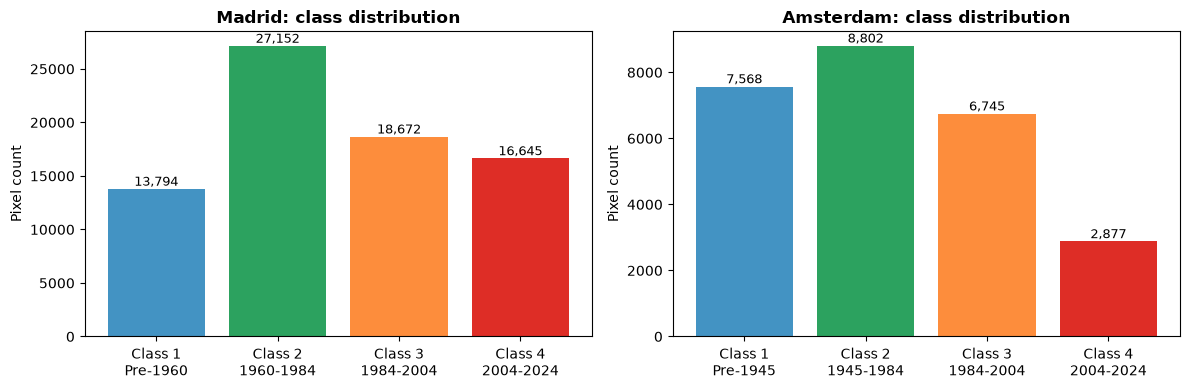

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, feat) in zip(axes, [('Madrid', features_madrid),
                                   ('Amsterdam', features_amsterdam)]):
    labels  = CLASS_LABELS[name]
    classes = [1, 2, 3, 4]
    counts  = [(feat['age_class'] == c).sum() for c in classes]
    bars = ax.bar([f'Class {c}\n{labels[c]}' for c in classes], counts,
                  color=[CLASS_COLORS[c] for c in classes], edgecolor='none')
    for bar, n in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{n:,}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Pixel count')
    ax.set_title(f'{name}: class distribution', fontweight='bold')
plt.tight_layout(); plt.show()

---

## 3.8 Standardisation

Unchanged in method, and the protocol point is worth restating because it is the one place a
transfer pipeline most easily leaks: **the scaler is fit on Madrid only** and applied to
Amsterdam. Fitting on both cities would let Amsterdam's distribution inform the
transformation, which is not available when deploying to a genuinely unseen city.

Scaling matters because Notebook 4's prototype transfer assigns by **Euclidean distance**,
which weights each feature in proportion to its spread. The tree model is invariant to
monotone rescaling; the prototype step is not.

> **One honest caveat.** The scaler is fit on all Madrid pixels, including those that later
> land in validation folds. This is standard practice and its effect on a mean/variance
> transform is negligible, but it is technically transductive and we report it as such
> rather than claiming a perfectly nested pipeline.

In [10]:
TARGET_COL = 'age_class'

X_madrid    = features_madrid[FEATURE_COLS].values.astype(np.float64)
y_madrid    = features_madrid[TARGET_COL].values.astype(int)
X_amsterdam = features_amsterdam[FEATURE_COLS].values.astype(np.float64)
y_amsterdam = features_amsterdam[TARGET_COL].values.astype(int)

for name, X in [('Madrid', X_madrid), ('Amsterdam', X_amsterdam)]:
    n_nan = np.isnan(X).any(axis=1).sum()
    print(f'{name}: {X.shape}  NaN check: {"OK" if n_nan == 0 else f"WARNING {n_nan}"}')

scaler = StandardScaler()
X_madrid    = scaler.fit_transform(X_madrid)     # fit on Madrid ONLY
X_amsterdam = scaler.transform(X_amsterdam)
print('Standardised (scaler fit on Madrid only).')

Madrid: (76263, 84)  NaN check: OK
Amsterdam: (25992, 84)  NaN check: OK
Standardised (scaler fit on Madrid only).


---

## 3.9 Save Preprocessed Data

**CHANGE 4.** The provided pkl stores the feature matrix and nothing else, which is why
adding a single feature required rebuilding this entire notebook from the parquets. We
avoid inflicting that on the next iteration by also carrying:

- `weighted_mean_year` — the continuous target, so classes can be re-binned (for a different
  city boundary, or an ordinal reformulation) without another rebuild
- `coverage_*` — retained separately from the feature matrix so it can be used as a sample
  weight without also being an input
- `feat_groups` — including the new groups, so Notebook 4 can run group-wise ablations
- `legacy_60` — the original column list, so the baseline can be reproduced exactly for the
  ablation table

We write to **`preprocessed_v2.pkl`** and leave the original file untouched, so the baseline
remains reproducible.

In [12]:
import pickle
from pathlib import Path

output_dir = Path('./data/preprocessed')
output_dir.mkdir(parents=True, exist_ok=True)

data = {
    'X_madrid':            X_madrid,
    'y_madrid':            y_madrid,
    'X_amsterdam':         X_amsterdam,
    'y_amsterdam':         y_amsterdam,
    'feature_names':       FEATURE_COLS,
    'scaler':              scaler,
    'pixel_ids_madrid':    features_madrid[PID].values,
    'pixel_ids_amsterdam': features_amsterdam[PID].values,
    # ── CHANGE 4: carried so no future change needs another rebuild ─────────
    'year_madrid':         features_madrid['weighted_mean_year'].values,
    'year_amsterdam':      features_amsterdam['weighted_mean_year'].values,
    'coverage_madrid':     (features_madrid['coverage'].values if HAS_COVERAGE else None),
    'coverage_amsterdam':  (features_amsterdam['coverage'].values if HAS_COVERAGE else None),
    'legacy_60':           LEGACY_60,
    'feat_groups': {
        'overall': FEAT_OVERALL, 'indices': FEAT_INDICES, 'early': FEAT_EARLY,
        'late': FEAT_LATE, 'yoy': FEAT_YOY, 'indicators': FEAT_IND,
        'contrast': FEAT_CONTRAST, 'slope': FEAT_SLOPE, 'coverage': FEAT_COVERAGE,
    },
}

save_path = output_dir / 'preprocessed_v2.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(data, f)
print(f'Saved to: {save_path}  ({save_path.stat().st_size/1024/1024:.1f} MB)')
print(f'  {X_madrid.shape[0]:,} Madrid x {X_madrid.shape[1]} features')
print(f'  {X_amsterdam.shape[0]:,} Amsterdam x {X_amsterdam.shape[1]} features')

Saved to: data/preprocessed/preprocessed_v2.pkl  (67.9 MB)
  76,263 Madrid x 84 features
  25,992 Amsterdam x 84 features


---

## 3.10 Summary

Steps 1–9 are the provided pipeline. Steps marked **CHANGE** are ours.

1. **Loaded** both cities' parquets
2. **Assigned age classes** from `weighted_mean_year` with city-specific boundaries
3. **Flattened** to one best QA-valid observation per pixel-year, removing haze rows
   — **CHANGE 4:** `coverage` retained rather than dropped
4. **Recorded period coverage** before gap-filling
5. **Filled time-series gaps** by linear interpolation with edge fill
6. **Computed 5 spectral indices** (SAVI and ENDISI tested and rejected — see 3.6)
7. **Aggregated to one row per pixel**, 60 original temporal features
   — **CHANGE 1:** +12 contrast features (late − early)
   — **CHANGE 2:** +11 trend slopes
   — **CHANGE 3:** +1 `coverage`
   — **84 features total**
8. **Checked** the new columns for degeneracy and near-duplication
9. **Standardised** with `StandardScaler` fit on Madrid only
10. **Saved** to `preprocessed_v2.pkl`, carrying the continuous target and coverage
    — **CHANGE 4**

### What this bought, and how it was measured

| Configuration | Madrid CV (blocked) |
|---|---|
| Legacy 60 features | 0.6931 |
| + contrast | 0.6935 *(+0.0004, 2/5 folds)* |
| + contrast + slope | 0.6953 *(+0.0022, **5/5 folds**)* |
| + coverage feature | **0.6955** *(+0.0024, 4/5 folds)* |
| + coverage as weight instead | 0.6938 *(rejected)* |

Individually small. Reported with fold-win counts because at ±0.012 fold noise a +0.002
mean difference is only credible if it holds in every fold — which the slope features did.

Combined with the extended neighbourhood scales in Notebook 4, Madrid CV moves
**0.6849 → 0.7000** and Amsterdam 25-shot **0.6340 → 0.6494**.

**Next:** Notebook 4 (v3) loads `preprocessed_v2.pkl` and trains the final model.